# Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd



# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [2]:
from func_plots import plot_radar_reduction_potential, plot_area_size_shift_per_disturbances, plot_disturbance_signal_duration, plot_signal_counts_by_diff_year, calculate_plot_overlap_percentage
from func_helper import parse_custom_colors, format_label
from func_file_io import load_data
from func_preprocessing import calculate_size_shift_difference

# Plotting

In this section, we plot the function to analyze the radar potential. The plots illustrate:

- **Appendix 1**: The combination of many s1dm polygons into 1 event (coresponding ids event
- **Radar detection potential**: The ability of radar change detection to detect different kinds of disturbance types.
- **Area and location changes**: The variation in disturbance areas and their spatial distribution over time.
- **Sentinel-1 signal duration**: The duration of the radar signal detected by Sentinel-1, highlighting how long each disturbance is observable by the radar.
- **Yearly Lag between IDS & S1DM**: Ofset of detection between ODS and S1DM
- **Appendix 2**: KDE distribution per disturbance Type how much IDS and S1DM overlap

These plots help visualize the relationship between disturbance characteristics and the radar's ability to detect changes over different temporal and spatial scales.


In [3]:
# Load environment variables from the .env file
env_path = Path('/work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

# Define file paths for shapefiles and output locations
usa_filepath = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region_{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
#refdm_path = f"{os.getenv('RESULTS')}/s1dm.shp"
s1_tiles_boundary_path = f"{os.getenv('RESULTS')}/radar_results/s1cd_tiles_bounds_region_{region_id}.shp"

# TCC Paths
forest_map_path = f"{os.getenv('TCC_PATH')}/wp1_nlcd_tcc_conus_2017_v2021_4_20m_EPSG_4326_cropped_region_08.tif"
forest_map_downsampled_path = f"{os.getenv('TCC_PATH')}/intermediate_tcc_map_region_8.nc"
tcc_map_region_8 = f"{os.getenv('TCC_PATH')}/tcc_map_region_8.nc"

figure_output_path = f"{os.getenv('FIGURES')}"
if not os.path.exists(figure_output_path):
        os.makedirs(figure_output_path)
        
# Retrieve environment variables
s1_tiles_folder = os.getenv('SENTINEL1_TILES')
print(f"S1 Tiles folder: {s1_tiles_folder}")
if not os.path.isdir(s1_tiles_folder):
    raise FileNotFoundError(f"The folder {s1_tiles_folder} does not exist.")

figure_study_area_path = figure_output_path + "p1_f6_refdm_study_area.png"
figure_radar_reduction_potential_path = figure_output_path + "p1_f77_ids_refdm_radar_reduction_potential.png"
figure_s1_signal_appearances_path = figure_output_path + "p1_f8_s1_signal_appearances.png"
figure_year_lag_path = figure_output_path + "p1_f9_year_lag_ids_s1cd.png"
#figure_size_position_change_errrorbar_path = figure_output_path + "p1_f9_size_position_change_errrorbar.png"
figure_size_position_change_path = figure_output_path + "p1_f10_size_position_change.png"
figure_overlap_percentage_path = figure_output_path + "p1_f11_overlap_percentage.png"


print("Load the Forest Disturbances ...")
refdm_gdf = load_data(refdm_path)
ids_gdf = load_data(ids_path)

S1 Tiles folder: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/Data/S1_TILES_R8/s1_change_detection_northamerica/
Load the Forest Disturbances ...
Loading shapefile from: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/results_clean//radar_enhanced_forest_disturbance_mapping_region_08.shp
Loading shapefile from: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/results_clean//region_08_dca_filtered_ids_usda_polygons.shp


In [4]:
refdm_gdf

,IDX_D,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area,minicube_i,cube_amoun,geometry
0,bark_beetle_2016_0,2016,E087N024T3,0.002669,0,bark_beetle,2016,8,1,23857,None,NaN,None,NaN,0.015911,1.295255,0.002669,[349],1,"MULTIPOLYGON (((8879455.355 2589781.483, 88794..."
1,bark_beetle_2016_1,2016,E093N030T3,0.000578,1,bark_beetle,2016,8,1,23858,None,NaN,None,NaN,0.010146,1.243389,0.000578,[833],1,"MULTIPOLYGON (((9525158.882 3138111.007, 95251..."
2,bark_beetle_2016_12,2016,E090N027T3,0.003326,12,bark_beetle,2016,8,1,23874,None,NaN,None,NaN,0.043778,1.104247,0.003326,"[706, 707]",2,"MULTIPOLYGON (((9231075.119 2808574.363, 92310..."
3,bark_beetle_2016_47,2016,E084N027T3,0.013320,47,bark_beetle,2016,8,1,23944,None,NaN,None,NaN,0.011143,2.822145,0.013320,[47],1,"MULTIPOLYGON (((8613214.991 2939162.093, 86132..."
4,bark_beetle_2016_8,2016,E090N027T3,0.019959,8,bark_beetle,2016,8,1,23866,None,NaN,None,NaN,0.014324,1.443711,0.019959,[706],1,"POLYGON ((9231021.578 2810803.837, 9231058.228..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,wind_2020_2048,2021,E084N024T3,0.000533,2048,wind,2020,8,16,26829,None,NaN,None,NaN,0.035249,10.208057,0.000533,"[67, 68]",2,"MULTIPOLYGON (((8642745.798 2471100.919, 86426..."
5611,wind_2020_2055,2018,E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.130823,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6,"MULTIPOLYGON (((9081603.076 3145101.301, 90816..."
5612,wind_2020_2055,2019,E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.064821,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6,"MULTIPOLYGON (((9081273.19 3144975.279, 908130..."
5613,wind_2020_2055,2020,E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.198790,38.236496,0.000594,"[665, 668, 670, 675, 682]",5,"MULTIPOLYGON (((9083842.468 3145447.491, 90838..."


/tmp/ipykernel_2287034/3294327738.py:27: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=18)  # Increase legend font size


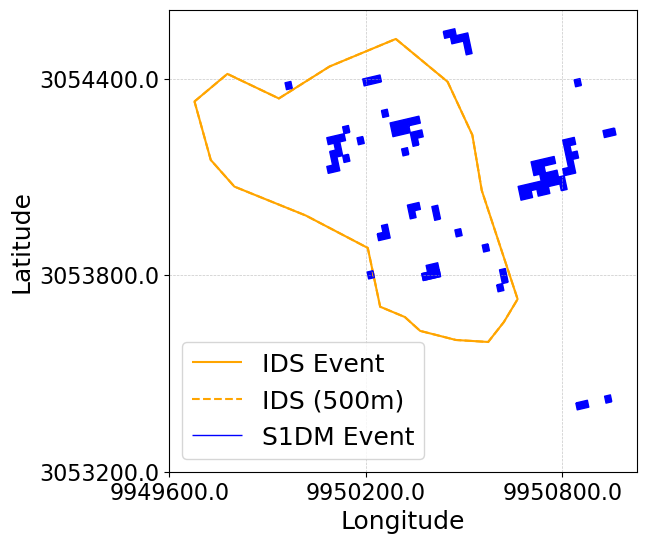

In [5]:
import matplotlib.pyplot as plt

idx = 'defoliators_2016_100'
filtered_refdm = refdm_gdf[refdm_gdf['IDX_D'] == idx]
# Extract the single geometry from ids_gdf (row 100)
ids_geometry = ids_gdf.iloc[100:101]['geometry']

# Create a 500-meter buffer around the geometry
buffered_geometry = ids_geometry.buffer(0.005)

# Plot all geometries in a single plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the original ids_gdf geometry in orange
ids_geometry.boundary.plot(ax=ax, color='orange', label='IDS Event')

# Plot the buffered geometry in dotted orange
buffered_geometry.boundary.plot(ax=ax, color='orange', linestyle='--', label='IDS (500m)')

# Plot the filled S1DM geometry
filtered_refdm.plot(ax=ax, color='blue', alpha=1, label='S1DM Event')

# Overlay the S1DM boundary with a thicker line
filtered_refdm.boundary.plot(ax=ax, color='blue', linewidth=1, label='S1DM Event')

# Add legend and labels with larger font sizes
ax.legend(loc='lower left', fontsize=18)  # Increase legend font size
ax.set_xlabel('Longitude', fontsize=18)  # Larger font size for x-axis label
ax.set_ylabel('Latitude', fontsize=18)  # Larger font size for y-axis label

# Add grid lines (tick marks)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Set a maximum of 3 ticks for each axis and format them
x_ticks = ax.get_xticks()[::max(1, len(ax.get_xticks()) // 3)]
y_ticks = ax.get_yticks()[::max(1, len(ax.get_yticks()) // 3)]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Format tick labels to 1 decimal place and increase font size
ax.set_xticklabels([f"{tick:.1f}" for tick in x_ticks], fontsize=16)
ax.set_yticklabels([f"{tick:.1f}" for tick in y_ticks], fontsize=16)

# Save the figure as PNG with 300 DPI
plt.savefig(f"{figure_output_path}appendix_1.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


In [6]:
import geopandas as gpd
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union

def merge_geometries_and_keep_columns(gdf):
    """
    Merge geometries by 'IDX_D' and 'S1_YEAR' into a single geometry (MultiPolygon) and
    keep the first value for all other columns.

    Parameters:
    - gdf (GeoDataFrame): The input GeoDataFrame with geometries and other columns.
    
    Returns:
    - GeoDataFrame: A new GeoDataFrame with merged geometries and first values of other columns.
    """
    grouped_gdf = gdf.groupby(['IDX_D', 'S1_YEAR']).apply(
        lambda group: group.unary_union  # Merge the geometries within each group
    ).reset_index(name='geometry')

    # Step 2: For other columns, keep the first value
    for column in gdf.columns:
        if column not in ['IDX_D', 'S1_YEAR', 'geometry']:  # Skip 'IDX_D', 'S1_YEAR', and 'geometry'
            # Ensure the aggregation keeps the first value for each group
            grouped_gdf[column] = gdf.groupby(['IDX_D', 'S1_YEAR'])[column].first().values

    # Step 3: Convert to GeoDataFrame and ensure geometries are MultiPolygons if they aren't already
    grouped_gdf = gpd.GeoDataFrame(grouped_gdf, geometry='geometry')

    # Ensure the geometries are MultiPolygons if they aren't already
    grouped_gdf['geometry'] = grouped_gdf['geometry'].apply(
        lambda geom: MultiPolygon([geom]) if not isinstance(geom, MultiPolygon) else geom
    )

    # Step 4: Set CRS (coordinate reference system) if needed
    grouped_gdf.set_crs(gdf.crs, allow_override=True, inplace=True)

    return grouped_gdf

In [7]:
refdm_gdf_yearly_aggregated = merge_geometries_and_keep_columns(refdm_gdf)

/tmp/ipykernel_2287034/27210790.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lambda group: group.unary_union  # Merge the geometries within each group
/tmp/ipykernel_2287034/27210790.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_gdf = gdf.groupby(['IDX_D', 'S1_YEAR']).apply(


In [8]:
refdm_gdf_yearly_aggregated

,IDX_D,S1_YEAR,geometry,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area,minicube_i,cube_amoun
0,bark_beetle_2016_0,2016,"MULTIPOLYGON (((8879435.234 2589801.253, 88794...",E087N024T3,0.002669,0,bark_beetle,2016,8,1,23857,None,NaN,None,NaN,0.015911,1.295255,0.002669,[349],1
1,bark_beetle_2016_1,2016,"MULTIPOLYGON (((9525194.278 3138117.285, 95252...",E093N030T3,0.000578,1,bark_beetle,2016,8,1,23858,None,NaN,None,NaN,0.010146,1.243389,0.000578,[833],1
2,bark_beetle_2016_12,2016,"MULTIPOLYGON (((9231040.936 2808548.256, 92310...",E090N027T3,0.003326,12,bark_beetle,2016,8,1,23874,None,NaN,None,NaN,0.043778,1.104247,0.003326,"[706, 707]",2
3,bark_beetle_2016_47,2016,"MULTIPOLYGON (((8613233.253 2939162.959, 86132...",E084N027T3,0.013320,47,bark_beetle,2016,8,1,23944,None,NaN,None,NaN,0.011143,2.822145,0.013320,[47],1
4,bark_beetle_2016_8,2016,"MULTIPOLYGON (((9231021.578 2810803.837, 92310...",E090N027T3,0.019959,8,bark_beetle,2016,8,1,23866,None,NaN,None,NaN,0.014324,1.443711,0.019959,[706],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,wind_2020_2048,2021,"MULTIPOLYGON (((8642744.896 2471122.259, 86427...",E084N024T3,0.000533,2048,wind,2020,8,16,26829,None,NaN,None,NaN,0.035249,10.208057,0.000533,"[67, 68]",2
5611,wind_2020_2055,2018,"MULTIPOLYGON (((9081625.523 3145059.856, 90816...",E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.130823,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6
5612,wind_2020_2055,2019,"MULTIPOLYGON (((9081275.489 3144953.529, 90812...",E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.064821,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6
5613,wind_2020_2055,2020,"MULTIPOLYGON (((9083880.467 3145429.862, 90838...",E090N030T3,0.000594,2055,wind,2020,8,16,26846,None,NaN,None,NaN,0.198790,38.236496,0.000594,"[665, 668, 670, 675, 682]",5


In [9]:
# Save the GeoDataFrame as a shapefile
refdm_gdf_yearly_aggregated.to_file(refdm_path, driver='ESRI Shapefile')


In [10]:
from shapely.ops import unary_union

def remove_drought(gdf):
    return gdf[gdf['DCA_ID'] != 'drought']

def closest_s1_year(group):
    # Ensure that both 'S1_YEAR' and 'SURVEY_Y' are numeric
    group['S1_YEAR'] = pd.to_numeric(group['S1_YEAR'], errors='coerce')
    group['SURVEY_Y'] = pd.to_numeric(group['SURVEY_Y'], errors='coerce')
    
    # Calculate the absolute difference between 'S1_YEAR' and 'SURVEY_Y'
    group['S1_Y_diff'] = (group['S1_YEAR'] - group['SURVEY_Y']).abs()
    
    # Find the index of the row with the minimum difference
    closest_idx = group['S1_Y_diff'].idxmin()
    
    return group.loc[closest_idx, 'S1_YEAR']


def add_signal_duration_column(refdm_gdf, crs=None):
    """
    Fügt eine Signal-Dauer-Spalte basierend auf der Häufigkeit von IDX_D hinzu und aggregiert
    nach IDX_D, so dass jedes IDX_D nur einmal erscheint. Dabei wird die Geometrie der verschiedenen
    IDX_D-Ereignisse zu einem MultiPolygon zusammengeführt. Alle Spalten, die für jedes IDX_D denselben Wert haben,
    bleiben erhalten, während Spalten mit unterschiedlichen Werten entsprechend aggregiert werden.

    Parameter:
    - refdm_gdf (GeoDataFrame): Das GeoDataFrame mit der Spalte IDX_D.
    - crs (str oder dict, optional): Das CRS, das der Geometrie zugewiesen werden soll.

    Rückgabe:
    - refdm_gdf_aggregated (GeoDataFrame): Aggregiertes GeoDataFrame mit zusätzlicher 'signal_duration'-Spalte.
    """

    # Zähle, wie oft jedes IDX_D vorkommt
    signal_duration_counts = refdm_gdf.groupby('IDX_D').size().reset_index(name='signal_duration')
    
    # Wir erstellen eine Aggregationsstrategie für alle Spalten
    aggregation = {
        'geometry': unary_union  # Aggregiert Geometrien zu einem MultiPolygon
    }
    
    # Aggregiere für alle anderen Spalten
    for column in refdm_gdf.columns:
        if column != 'IDX_D' and column != 'geometry':  # Alle anderen Spalten außer IDX_D und geometry
            if refdm_gdf[column].nunique() == 1:  # Wenn alle Werte in der Spalte gleich sind
                aggregation[column] = 'first'  # Behalte den ersten Wert
            else:
                aggregation[column] = 'first'  # Ansonsten könnte man z.B. 'first' oder 'mean' verwenden
    
    # Aggregiere das GeoDataFrame nach IDX_D
    refdm_gdf_aggregated = refdm_gdf.groupby('IDX_D').agg(aggregation).reset_index()
    
    # Add the 'S1_YEAR' closest to 'SURVEY_Y' for each 'IDX_D'
    refdm_gdf_aggregated['S1_YEAR'] = refdm_gdf.groupby('IDX_D').apply(closest_s1_year).values
    
    # Setze die Geometriespalte explizit
    refdm_gdf_aggregated = refdm_gdf_aggregated.set_geometry('geometry')

    # Merge die gezählten Signal-Dauern in das aggregierte GeoDataFrame
    refdm_gdf_aggregated = refdm_gdf_aggregated.merge(signal_duration_counts, on='IDX_D', how='left')
    
    # Falls ein CRS übergeben wurde, weise es der Geometrie zu
    if crs:
        refdm_gdf_aggregated.set_crs(crs, allow_override=True, inplace=True)
    
    return refdm_gdf_aggregated


# Beispielanwendung
# Geben Sie das gewünschte CRS (z.B. "EPSG:4326" für WGS 84)
crs = "EPSG:4326"
refdm_gdf_yearly_aggregated = merge_geometries_and_keep_columns(refdm_gdf)
s1dm_frequency = add_signal_duration_column(refdm_gdf_yearly_aggregated, crs)

/tmp/ipykernel_2287034/27210790.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lambda group: group.unary_union  # Merge the geometries within each group
/tmp/ipykernel_2287034/27210790.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_gdf = gdf.groupby(['IDX_D', 'S1_YEAR']).apply(
/tmp/ipykernel_2287034/3642835911.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after gr

In [11]:
s1dm_frequency

,IDX_D,geometry,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,...,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area,minicube_i,cube_amoun,signal_duration
0,bark_beetle_2016_0,"MULTIPOLYGON (((8879494.09947 2589763.18167, 8...",2016,E087N024T3,0.002669,0,bark_beetle,2016,8,1,...,None,NaN,None,NaN,0.015911,1.295255,0.002669,[349],1,1
1,bark_beetle_2016_1,"MULTIPOLYGON (((9525201.21919 3138074.41482, 9...",2016,E093N030T3,0.000578,1,bark_beetle,2016,8,1,...,None,NaN,None,NaN,0.010146,1.243389,0.000578,[833],1,1
2,bark_beetle_2016_12,"MULTIPOLYGON (((9230985.94502 2808541.18563, 9...",2016,E090N027T3,0.003326,12,bark_beetle,2016,8,1,...,None,NaN,None,NaN,0.043778,1.104247,0.003326,"[706, 707]",2,1
3,bark_beetle_2016_47,"MULTIPOLYGON (((8613234.19315 2939141.21182, 8...",2016,E084N027T3,0.013320,47,bark_beetle,2016,8,1,...,None,NaN,None,NaN,0.011143,2.822145,0.013320,[47],1,1
4,bark_beetle_2016_8,"POLYGON ((9231021.57777 2810803.83706, 9231058...",2016,E090N027T3,0.019959,8,bark_beetle,2016,8,1,...,None,NaN,None,NaN,0.014324,1.443711,0.019959,[706],1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1924,wind_2020_2045,"MULTIPOLYGON (((8742684.83135 2628479.69478, 8...",2020,E087N024T3,0.019314,2045,wind,2020,8,16,...,None,NaN,None,NaN,1.499773,10.415631,0.019314,"[223, 231]",2,1
1925,wind_2020_2046,"MULTIPOLYGON (((8710888.21796 2627541.43126, 8...",2020,E087N024T3,0.000537,2046,wind,2020,8,16,...,None,NaN,None,NaN,0.268004,10.417135,0.000537,[131],1,4
1926,wind_2020_2047,"MULTIPOLYGON (((8760509.08789 2627211.7447, 87...",2020,E087N024T3,0.002682,2047,wind,2020,8,16,...,None,NaN,None,NaN,0.029666,10.412008,0.002682,[248],1,3
1927,wind_2020_2048,"MULTIPOLYGON (((8642688.05013 2471119.55269, 8...",2020,E084N024T3,0.003730,2048,wind,2020,8,16,...,None,NaN,None,NaN,0.037270,10.208057,0.003730,"[67, 68]",2,4


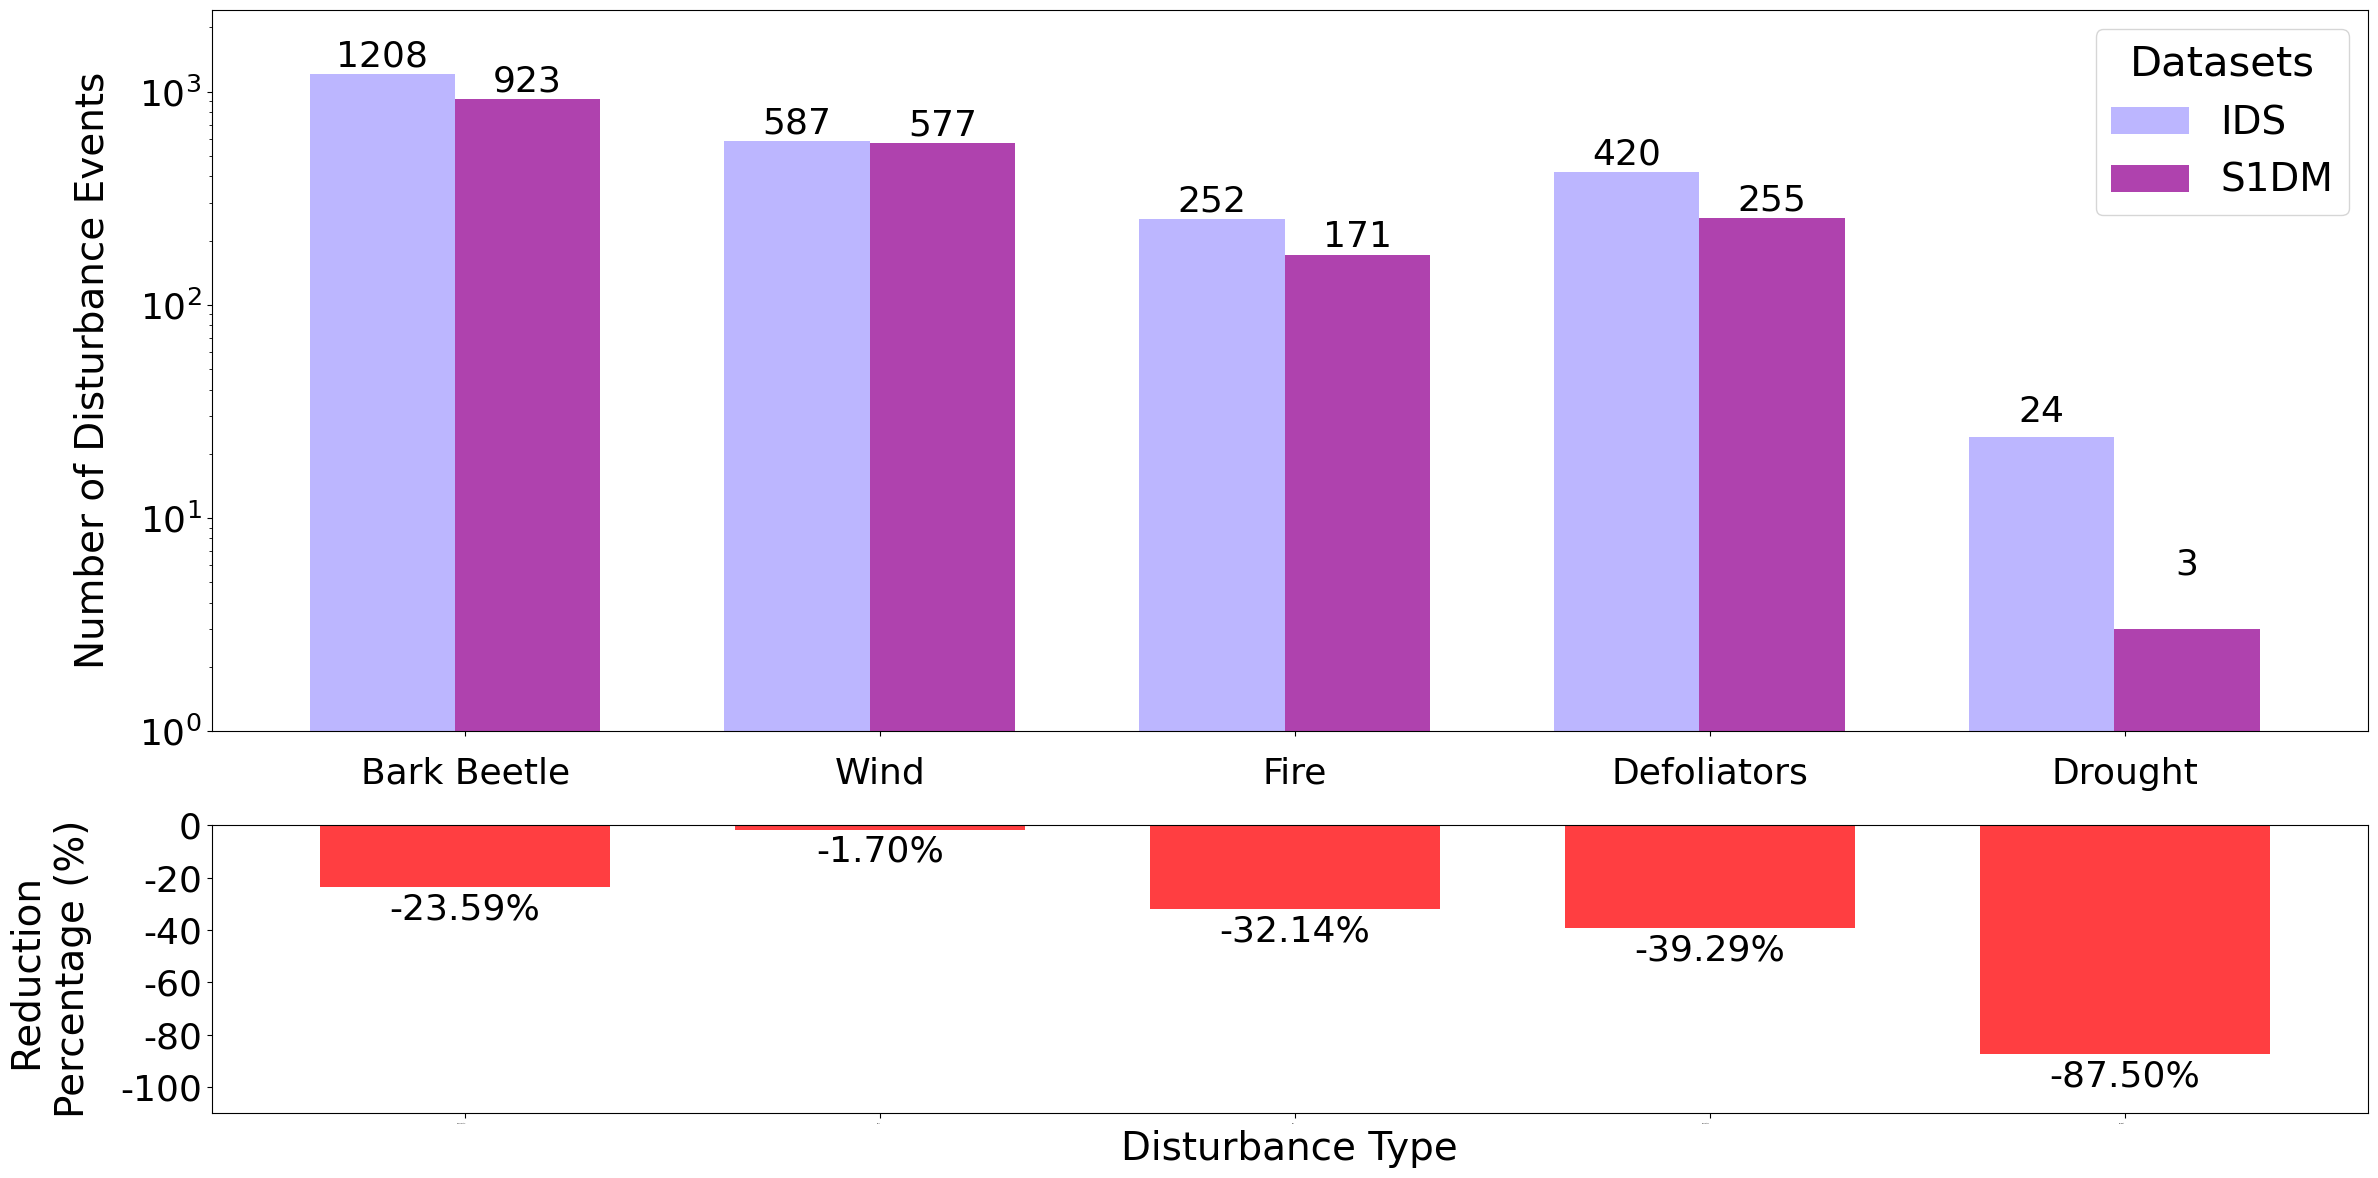

In [12]:
plot_radar_reduction_potential(s1dm_frequency, ids_gdf, save_path=figure_radar_reduction_potential_path, plot_reduction=True)
s1dm_cleaned = remove_drought(s1dm_frequency)

/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/shapely/measurement.py:44: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/shapely/constructive.py:285: RuntimeWarning: invalid value encountered in centroid
  return lib.centroid(geometry, **kwargs)
/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/shapely/measurement.py:44: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/shapely/constructive.py:285: RuntimeWarning: invalid value encountered in centroid
  return lib.centroid(geometry, **kwargs)
/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

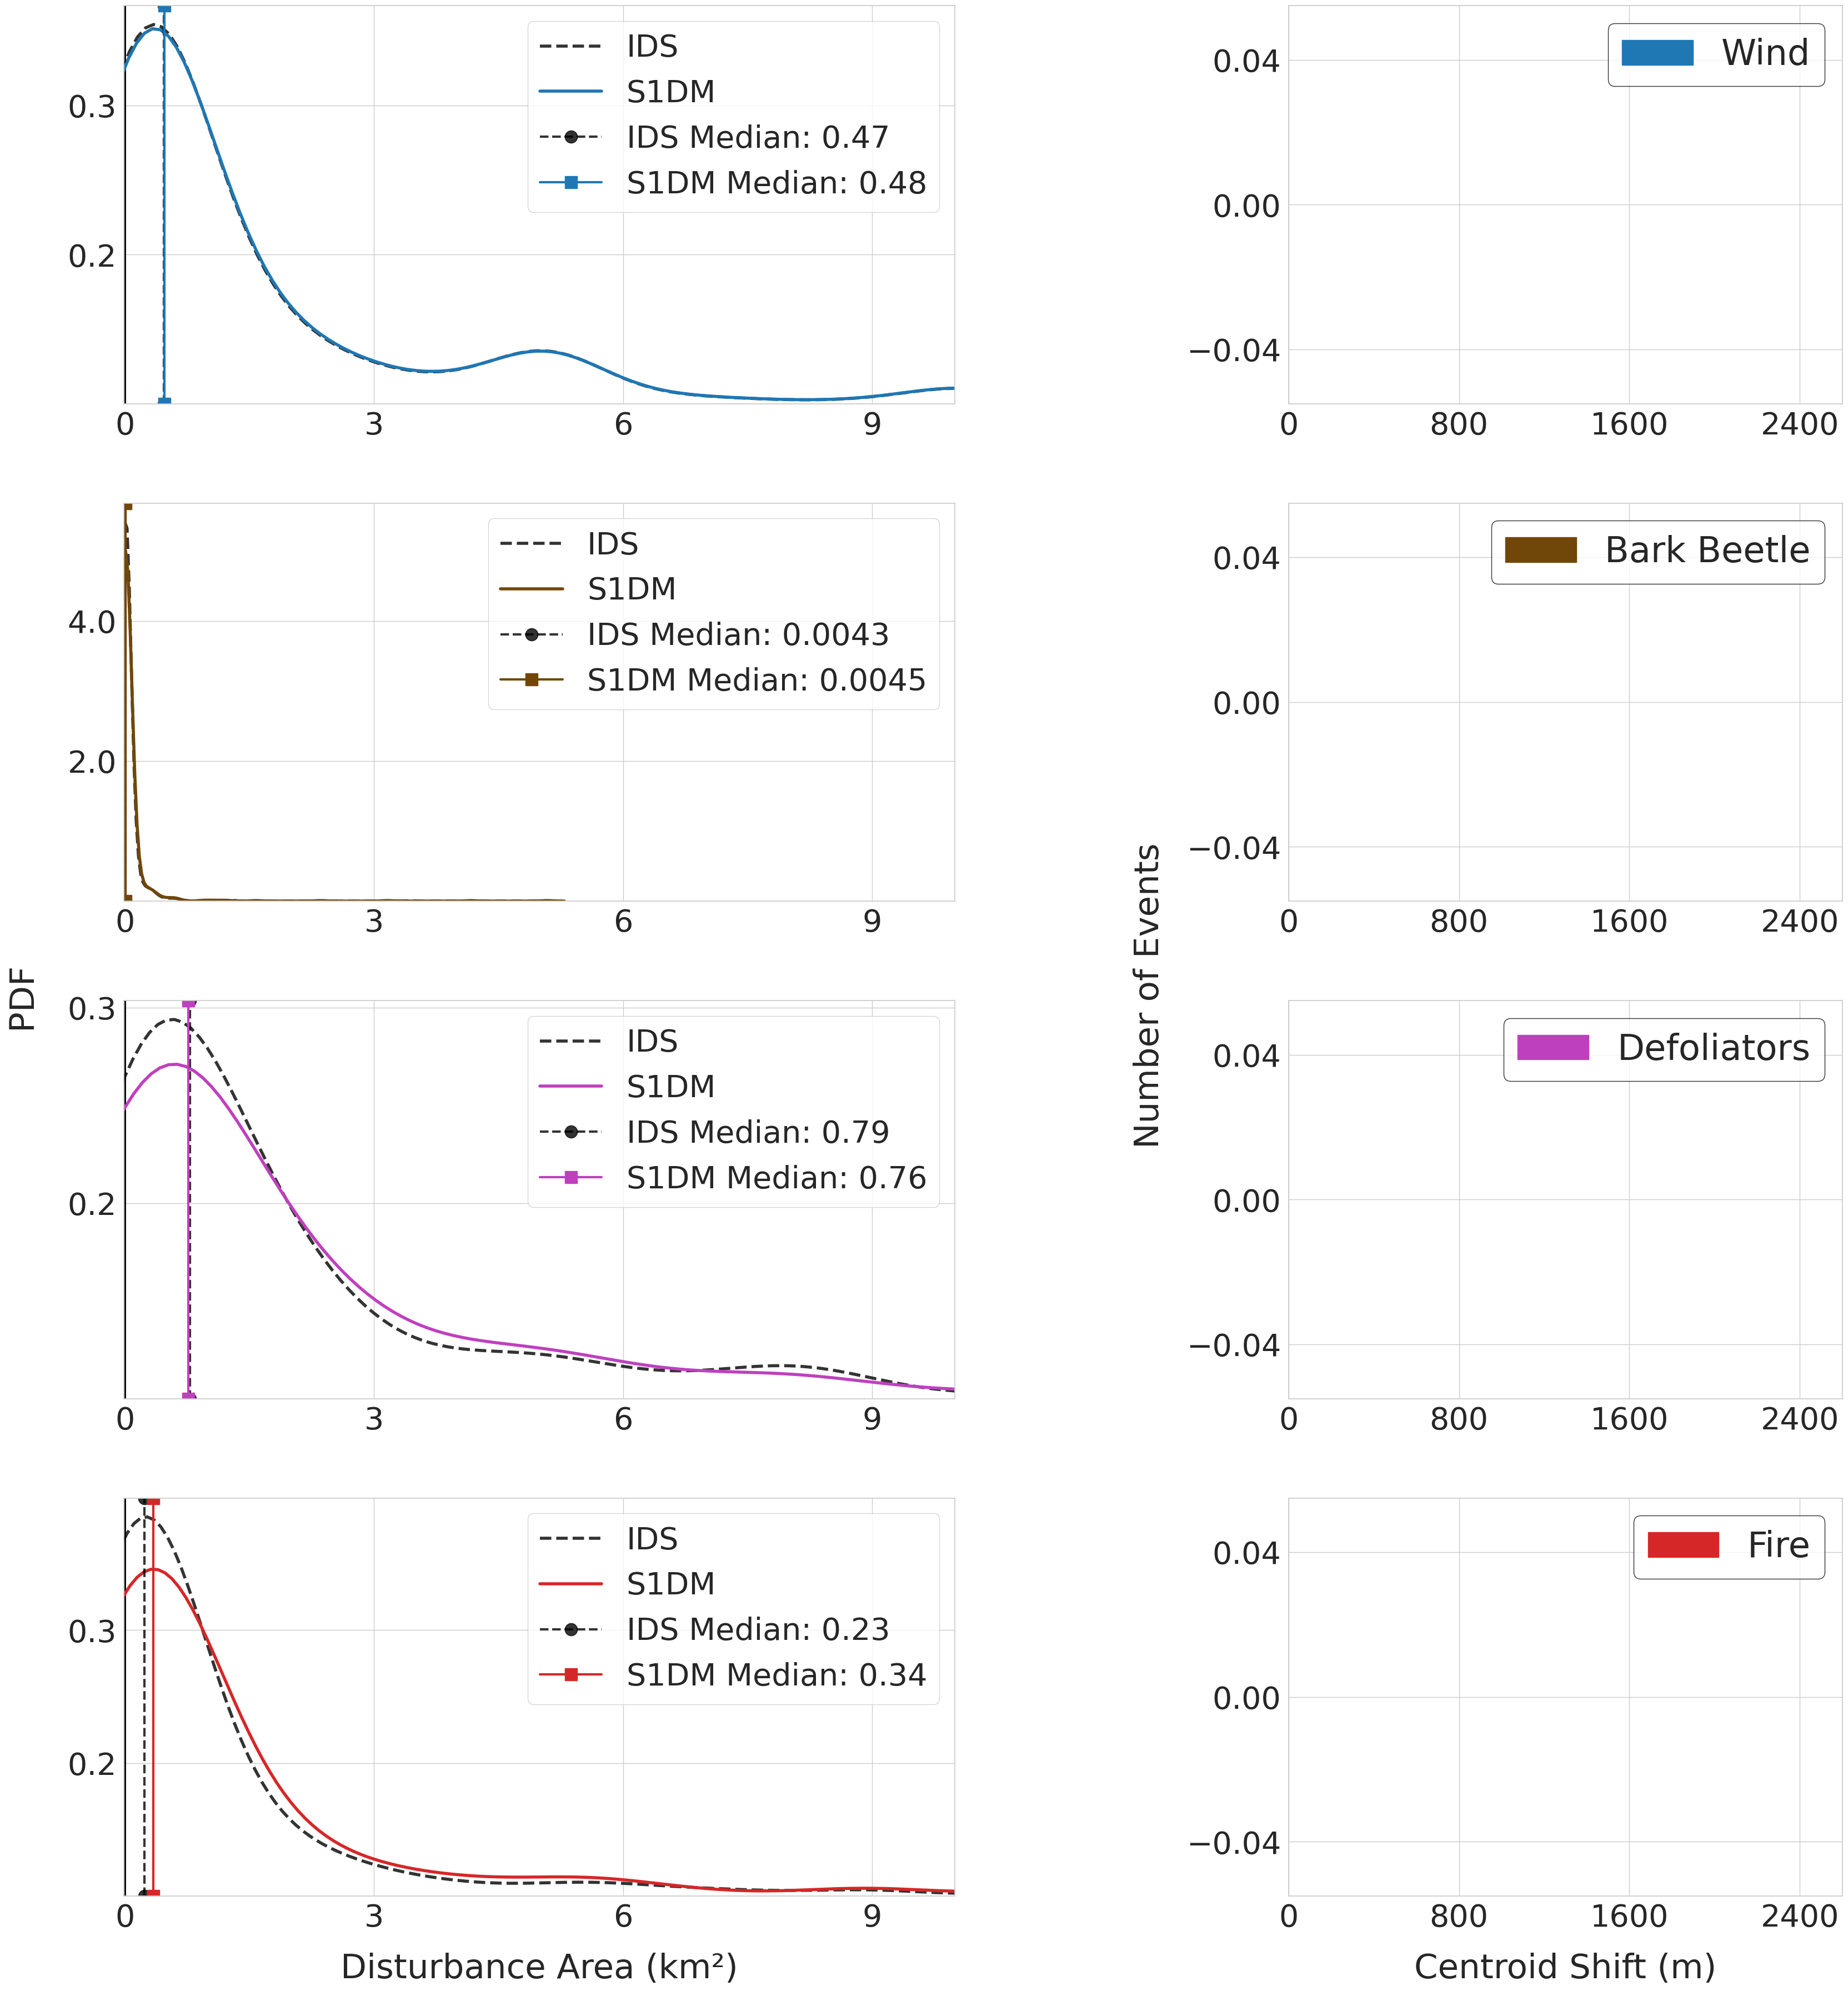

In [13]:
gdf = calculate_size_shift_difference(ids_gdf, s1dm_cleaned)
plot_area_size_shift_per_disturbances(gdf, ids_gdf, custom_colors, save_path=figure_size_position_change_path)

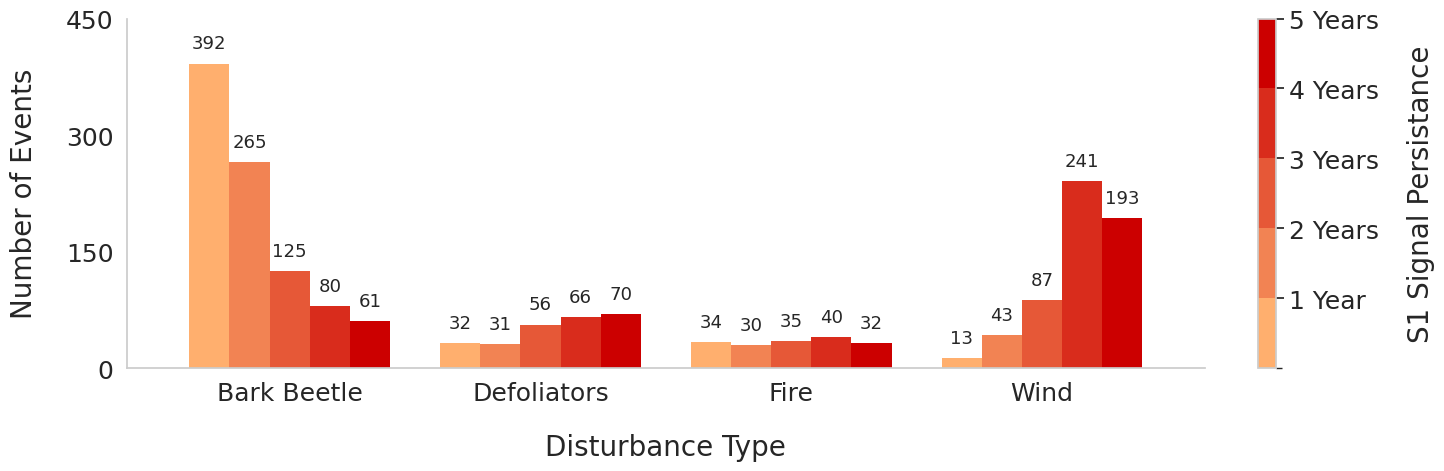

In [39]:
# Beispielanwendung
plot_disturbance_signal_duration(s1dm_cleaned, figure_s1_signal_appearances_path)

/home/sc.uni-leipzig.de/sy58xupo/anaconda3/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


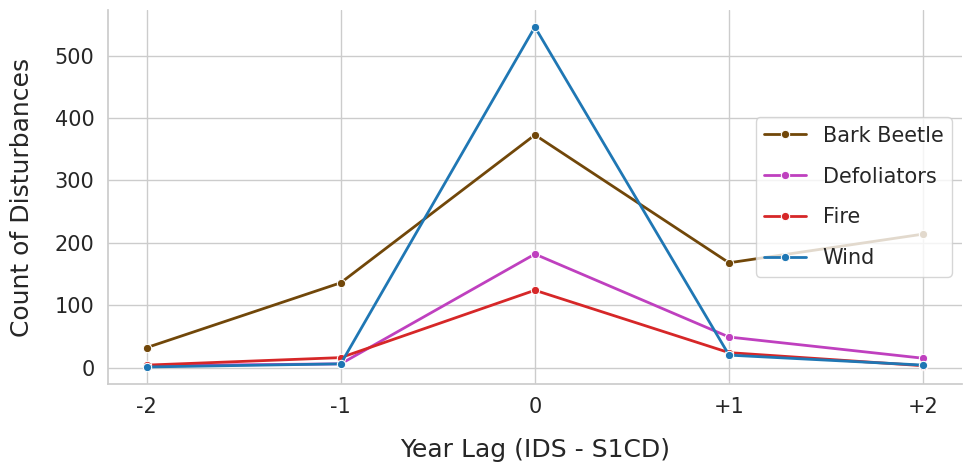

In [17]:
#s1dm_no_drougth = remove_drought(refdm_gdf_yearly_aggregated) 
s1dm_no_drougth = remove_drought(s1dm_frequency) 
plot_signal_counts_by_diff_year(s1dm_no_drougth, custom_colors, figure_year_lag_path)

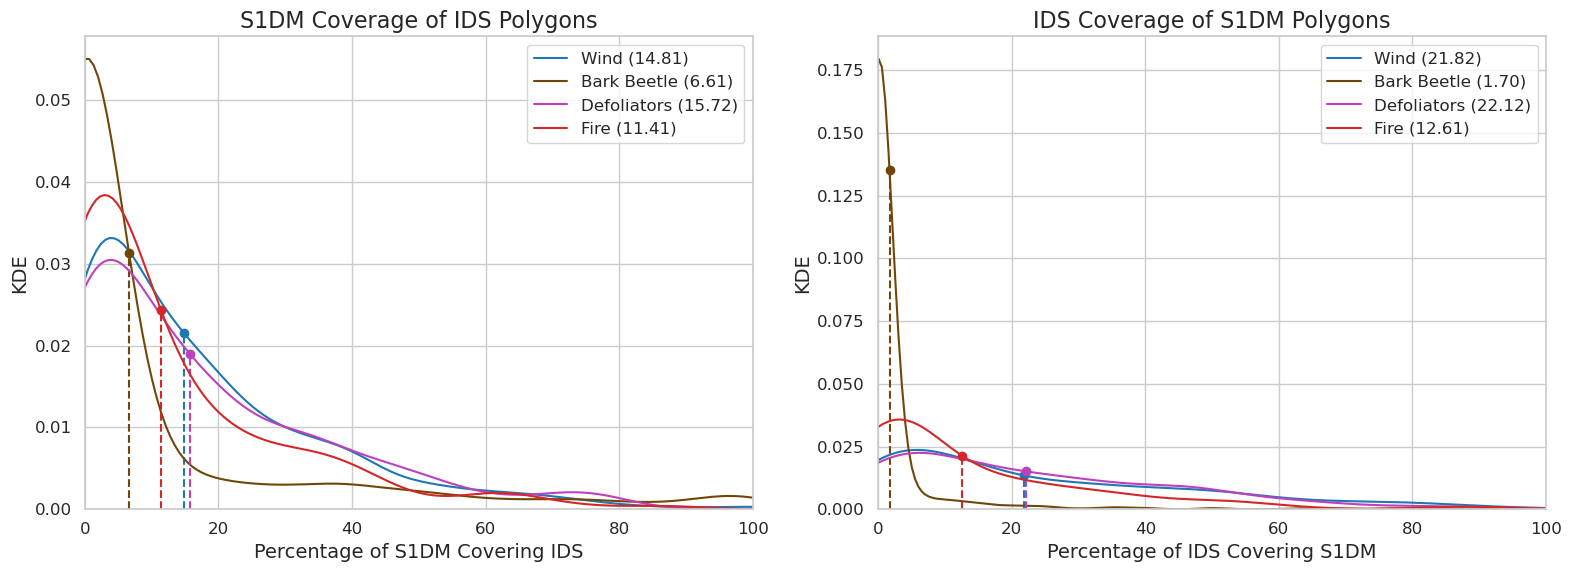

In [14]:
calculate_plot_overlap_percentage(ids_gdf, s1dm_no_drougth, custom_colors, figure_overlap_percentage_path)